# Notebook 1 : Exploration des données
Dataset utilisé : [UCI SMS Spam Collection](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# téléchargement automatique
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'text'])

print(f'Shape : {df.shape}')
df.head(10)

Shape : (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [8]:
print('=== Types ===')
print(df.dtypes)
print('\n=== Valeurs manquantes ===')
print(df.isnull().sum())
print('\n=== Distribution des labels ===')
print(df['label'].value_counts())
print(f'\nProportion spam : {df["label"].value_counts(normalize=True)["spam"]:.1%}')

=== Types ===
label    str
text     str
dtype: object

=== Valeurs manquantes ===
label    0
text     0
dtype: int64

=== Distribution des labels ===
label
ham     4825
spam     747
Name: count, dtype: int64

Proportion spam : 13.4%


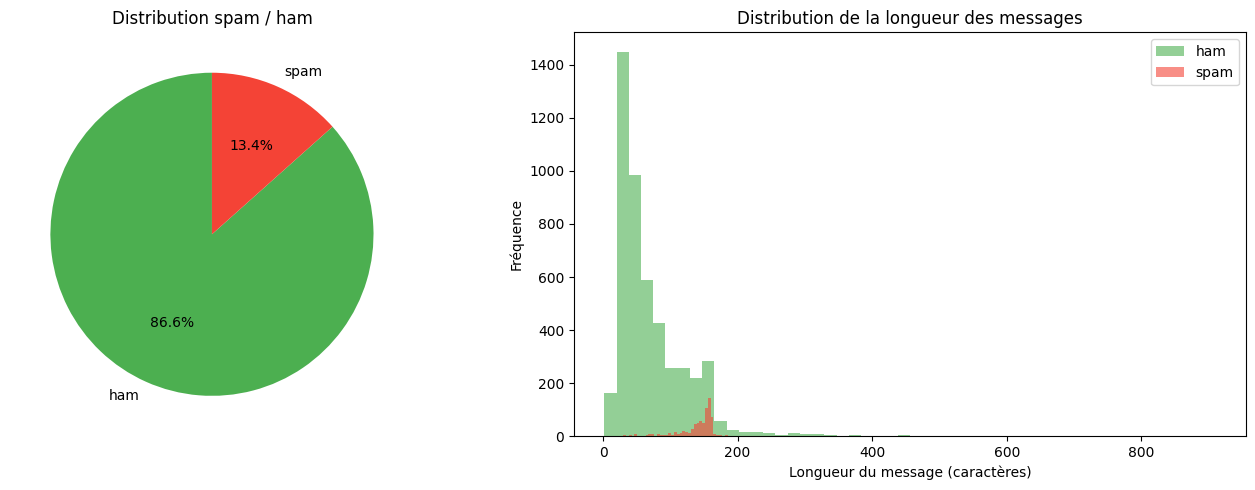

Longueur moyenne (ham) : 71.5
Longueur moyenne (spam): 138.7


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution spam / ham
counts = df['label'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Distribution spam / ham')

# Longueur des messages
df['text_length'] = df['text'].str.len()
for label, color in [('ham', '#4CAF50'), ('spam', '#F44336')]:
    subset = df[df['label'] == label]['text_length']
    axes[1].hist(subset, bins=50, alpha=0.6, label=label, color=color)
axes[1].set_xlabel('Longueur du message (caractères)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution de la longueur des messages')
axes[1].legend()

plt.tight_layout()
plt.show()

# Stats descriptives
print('Longueur moyenne (ham) :', df[df['label']=='ham']['text_length'].mean().round(1))
print('Longueur moyenne (spam):', df[df['label']=='spam']['text_length'].mean().round(1))

In [10]:
df[['label', 'text']].to_csv('data_raw.csv', index=False)
print(' data_raw.csv sauvegardé')

 data_raw.csv sauvegardé
